In [1]:
from pyLRT import RadTran, get_lrt_folder
from pyLRT.misc import planck_function
import matplotlib.pyplot as plt
import copy
import numpy as np
import scipy
import scipy.interpolate

LIBRADTRAN_FOLDER = get_lrt_folder()

In [2]:
# Unintegrated analysis 

slrt = RadTran(LIBRADTRAN_FOLDER)
slrt.options['rte_solver'] = 'disort'
slrt.options['source'] = 'solar'
slrt.options['wavelength'] = '200 2600'
slrt.options['output_user'] = 'lambda eglo eup edn edir'
slrt.options['zout'] = '0 5 TOA'
slrt.options['albedo'] = '0'
slrt.options['umu'] = '-1.0 1.0'
slrt.options['quiet'] = ''
slrt.options['sza'] = '0'
# slrt.options['output_process'] = 'integrate'

tlrt = copy.deepcopy(slrt)
tlrt.options['rte_solver'] = 'disort'
tlrt.options['source'] = 'thermal'
tlrt.options['output_user'] = 'lambda edir eup uu'
tlrt.options['wavelength'] = '2500 80000'
tlrt.options['mol_abs_param'] = 'reptran fine'
tlrt.options['sza'] = '0'
# tlrt.options['output_process'] = 'integrate'

# Add in a cloud
slrt_cld = copy.deepcopy(slrt)
slrt_cld.cloud = {'z': np.array([4, 3.7]),
                  'lwc': np.array([0, 0.5]),
                  're': np.array([0, 20])}

tlrt_cld = copy.deepcopy(tlrt)
tlrt_cld.cloud = {'z': np.array([4, 3.7]),
                  'lwc': np.array([0, 0.5]),
                  're': np.array([0, 20])}

# Run the RT
print('Initial RT')
sdata, sverb = slrt.run(verbose=True)
tdata, tverb = tlrt.run(verbose=True)
print('Cloud RT')
scdata, scverb = slrt_cld.run(verbose=True)
tcdata, tcverb = tlrt_cld.run(verbose=True)
print('Done RT')



Initial RT
**************************************************************************************
for fully resolving the spectral absorption features.
Use 'mol_abs_param crs' if you need higher spectral resolution.
**************************************************************************************
Cloud RT
**************************************************************************************
for fully resolving the spectral absorption features.
Use 'mol_abs_param crs' if you need higher spectral resolution.
**************************************************************************************
Done RT


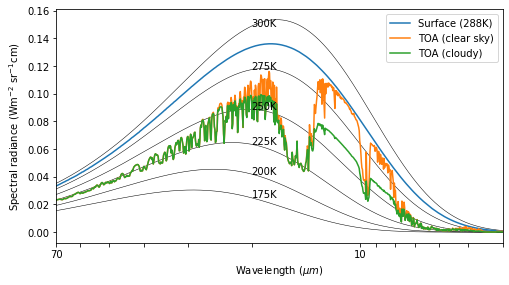

In [3]:
tclearsurf = scipy.interpolate.interp1d(np.log(tdata[::3, 0]), tdata[::3, 2])
tcleartoa = scipy.interpolate.interp1d(np.log(tdata[2::3, 0]), tdata[2::3, 2])
tcldtoa = scipy.interpolate.interp1d(np.log(tcdata[2::3, 0]), tcdata[2::3, 2])

xtlocs = np.linspace(np.log(tdata[0, 0]), np.log(tdata[-1, 0]), 1000)

wvlticks = [(list(range(200, 1000, 100))+
             list(range(1000, 10000, 1000))+
             list(range(10000, 71000, 10000))),
            (['0.2']+['']*7+
             ['1']+['']*8+
             ['10']+['']*5+['70'])]

plt.plot(xtlocs,
         tclearsurf(xtlocs)/np.pi, label='Surface (288K)')
plt.plot(xtlocs,
         tcleartoa(xtlocs)/np.pi, label='TOA (clear sky)')
plt.plot(xtlocs,
         tcldtoa(xtlocs)/np.pi, label='TOA (cloudy)')
for t in [300, 275, 250, 225, 200, 175]:
    plt.plot(xtlocs, 100*np.exp(2*xtlocs)*1e-18*
             planck_function(
                 t,
                 wavelength=np.exp(xtlocs)*1e-9), c='k', lw=0.5, zorder=-1)
    plwvl = wvlticks[0][-6]
    plt.text(np.log(plwvl), 100*plwvl**2*1e-18*
             planck_function(
                 t,
                 wavelength=plwvl*1e-9), str(t)+'K')

plt.xticks(np.log(wvlticks[0]), wvlticks[1])
plt.xlim(np.log(70000), np.log(4000))
plt.xlabel(r'Wavelength ($\mu m$)')
plt.ylabel(r'Spectral radiance (Wm$^{-2}$ sr$^{-1}$cm)')
plt.legend()

fig = plt.gcf()
fig.set_size_inches(8, 4.3)
# fig.savefig('cloud_temp.pdf', bbox_inches='tight')

In [4]:
# Integrated Analysis 

slrt = RadTran(LIBRADTRAN_FOLDER)
slrt.options['rte_solver'] = 'disort'
slrt.options['source'] = 'solar'
slrt.options['wavelength'] = '200 2600'
slrt.options['output_user'] = 'lambda eglo eup edn edir'
slrt.options['zout'] = '0 5 TOA'
slrt.options['albedo'] = '0'
slrt.options['umu'] = '-1.0 1.0'
slrt.options['quiet'] = ''
slrt.options['sza'] = '0'
slrt.options['output_process'] = 'integrate'

tlrt = copy.deepcopy(slrt)
tlrt.options['rte_solver'] = 'disort'
tlrt.options['source'] = 'thermal'
tlrt.options['output_user'] = 'lambda edir eup uu'
tlrt.options['wavelength'] = '2500 80000'
tlrt.options['mol_abs_param'] = 'reptran fine'
tlrt.options['sza'] = '0'
tlrt.options['output_process'] = 'integrate'

# Add in a cloud
slrt_cld = copy.deepcopy(slrt)
slrt_cld.cloud = {'z': np.array([4, 3.7]),
                  'lwc': np.array([0, 0.5]),
                  're': np.array([0, 20])}

tlrt_cld = copy.deepcopy(tlrt)
tlrt_cld.cloud = {'z': np.array([4, 3.7]),
                  'lwc': np.array([0, 0.5]),
                  're': np.array([0, 20])}

# Run the RT
print('Initial RT')
sdata, sverb = slrt.run(verbose=True)
tdata, tverb = tlrt.run(verbose=True)
print('Cloud RT')
scdata, scverb = slrt_cld.run(verbose=True)
tcdata, tcverb = tlrt_cld.run(verbose=True)
print('Done RT')



Initial RT
**************************************************************************************
for fully resolving the spectral absorption features.
Use 'mol_abs_param crs' if you need higher spectral resolution.
**************************************************************************************
Cloud RT
**************************************************************************************
for fully resolving the spectral absorption features.
Use 'mol_abs_param crs' if you need higher spectral resolution.
**************************************************************************************
Done RT


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


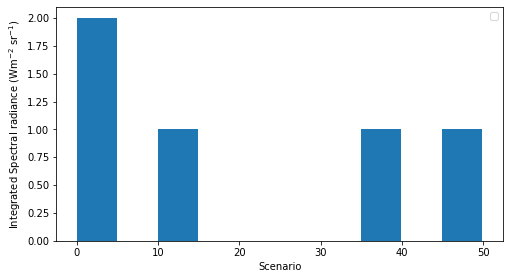

In [14]:
plt.hist(tdata[1] - tdata[2])
#plt.hist(tcdata[1] - tcdata[2])

plt.xlabel(r'Scenario')
plt.ylabel(r'Integrated Spectral radiance (Wm$^{-2}$ sr$^{-1}$)')
plt.legend()

fig = plt.gcf()
fig.set_size_inches(8, 4.3)

In [7]:
print(tcdata)

[[2500.312         0.          387.3257      107.7127304   123.2895889 ]
 [2500.312         0.          254.9032       35.89530563   81.83654022]
 [2500.312         0.          212.0494        0.           69.66970825]]


In [13]:
tcverb

{'wavelengths': <xarray.Dataset>
 Dimensions:    (wvl: 12097)
 Coordinates:
   * wvl        (wvl) float64 2.5e+03 2.5e+03 2.501e+03 ... 7.911e+04 7.968e+04
 Data variables:
     OutputWVL  (wvl) float64 2.5e+03 2.5e+03 2.501e+03 ... 7.905e+04 7.968e+04
     Weights    (wvl) float64 0.4302 0.5698 0.1868 0.09398 ... 0.2825 0.7175 1.0,
 'profiles': <xarray.Dataset>
 Dimensions:  (lc: 49)
 Coordinates:
   * lc       (lc) int64 0 1 2 3 4 5 6 7 8 9 10 ... 39 40 41 42 43 44 45 46 47 48
 Data variables:
     z        (lc) float64 115.0 110.0 105.0 100.0 95.0 ... 4.0 3.0 2.0 1.0 0.0
     p        (lc) float64 4e-05 7e-05 0.00014 0.00032 ... 795.0 898.8 1.013e+03
     T        (lc) float64 300.0 240.0 208.8 195.1 ... 268.7 275.2 281.7 288.2
     air      (lc) float64 9.681e+11 2.143e+12 5.03e+12 ... 2.311e+19 2.546e+19
     o3       (lc) float64 4.844e+03 1.072e+05 1.007e+06 ... 6.779e+11 6.778e+11
     o2       (lc) float64 9.107e+10 2.573e+11 7.046e+11 ... 4.834e+18 5.325e+18
     h2o      (lc